# 01 — Output

Covers `karpathy.py` lines 244–276, the *Machine Learning - Output* section, plus
the imports at lines 1–2 and `softmax` from lines 75–79: taking a model that already exists and drawing text
out of it.

Nothing here trains anything. `generate` asks some function for a score over every
possible next token, turns those scores into probabilities, draws one, and repeats.
Which function it asks is an argument — `logit_model` — so the last section swaps
in a model built entirely out of counting, and no neural network appears in this
notebook at all.

Code cells reproduce the source verbatim, dedented where a fragment sits inside a
function. Anything that is *not* from the source is marked as such.

Let's talk about generating sequences of tokens.

The tokens might be letters in english names, or words in the lyrics of the first three Beatles albums. We don't know and iMt doesn't matter. If we have an "alphabet" or "vacabulary" of $n$ tokens, a reasonable thing to do would be to give each token a probability, then sample according to that. Remember that a probability distribution looks like:

$$
P = \{ p_i \in [0,1] \mid \sum p_i = 1 \}
$$

So, for example, given a vocabulary of three tokens $T=\{ t_1, t_2, t_3 \}$ like $[A,B,C]$ we might have $P=\{ 0.5, 0.25, 0.25 \}$ we know the first token s twice as often as the others. We can generate according to this simple model easily:

In [22]:
import random
random.choices(['a', 'b', 'c'], weights=[0.5, 0.25, 0.25],k=10)

['c', 'c', 'a', 'a', 'b', 'a', 'a', 'a', 'a', 'b']

## Logits and probabilitie
_lines 75–79_

Sometimes dealing with real probabilities is a hassle or for experimental reasons we'd like to use something more like _weights_. It would be almost the same to say $\{ 61, 29, 31 \}$. Logits are a nice way to do that - they are simply a mapping from probabilites onto the whole line, thus:


$$
\begin{align}
\mathit{logit} &: [0,1] \to \mathbb{R} \\
& p \mapsto \ln( \frac{p}{1-p} )
\end{align}
$$

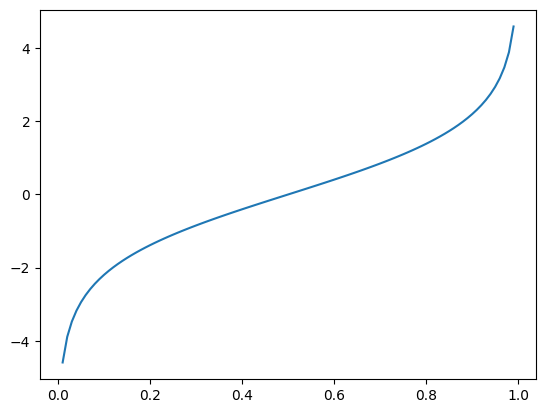

In [25]:
import math
def logit(p):
    return math.log(p/(1.0-p))

import matplotlib.pyplot as plt

X=[x/100.0 for x in range(1,100)]
Y=[ logit(x) for x in X]
plt.plot(X,Y)

In [32]:
good_weights = [63, 21, 19]
print([w/sum(weights) for w in weights])

bad_weights = good_weights + [0]
print([w/sum(bad_weights) for w in bad_weights])

[0.6116504854368932, 0.20388349514563106, 0.18446601941747573]
[0.6116504854368932, 0.20388349514563106, 0.18446601941747573, 0.0]


In [34]:
softmax(good_weights)

AttributeError: 'int' object has no attribute 'data'

In [33]:
def softmax(logits):
    max_val = max(val.data for val in logits)
    exps = [(val - max_val).exp() for val in logits]
    total = sum(exps)
    return [e / total for e in exps]

def tokens_to_text(tokens, token_type):
    return ('' if token_type == 'letter' else ' ').join(tokens)

## 1.2 Turning tokens back into text — lines 245–246

The tokenizer's inverse, and the one place the two token types differ: characters
butt together, words need spaces between them.

Other times we'll  be given a list of weights and want to make it into a probability distribution. Thus, _softma()_:

$$
p_i \;=\; \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

Subtracting `max_val` first changes nothing mathematically — the constant cancels
between numerator and denominator — but it keeps `exp` away from overflow.

Note the type: `softmax` reaches for `val.data` and `.exp()`, so its inputs must be
`Value` objects rather than plain floats. For this notebook treat `Value` as a box
around a number; generation never calls `backward()`, so the box does nothing here.
Notebook 05 opens it.

# Generating a Sequence of Tokens



## 1.4 Setting up a generation run — lines 248–258

`logit_model=gpt` is the important argument. `generate` never mentions attention,
embeddings or weights — it only needs *something* it can call for logits, and the
default happens to be the transformer.

`seed` defaults to 42 rather than to system entropy, so a bare `generate(config)`
repeats exactly.

In [ ]:
def generate(config, num_samples=20, temperature=0.5, verbose=True, seed=None, logit_model=gpt):
    """Sample from the model. Returns a list of decoded strings.

    `temperature` is in (0, 1] to control the "creativity" of generated text, low to high.
    """
    seed = 42 if seed is None else seed
    random.seed(seed)
    n_layer, block_size, vocab_size = config['n_layer'], config['block_size'], config['vocab_size']
    uchars, BOS, token_type = config['uchars'], config['BOS'], config['token_type']
    if verbose:
        print(f"Generating {num_samples} samples at T={temperature} with seed {seed}")

## 1.5 The sampling loop — lines 260–276

Each sample starts from `BOS` with an empty cache and runs until the model emits
`BOS` again or the context window fills.

`temperature` divides the logits before the softmax:

$$
p_i \;=\; \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}
$$

As $T \to 0$ the largest logit dominates and sampling becomes deterministic; at
$T = 1$ the model's own distribution is used unchanged. Values above 1 flatten the
distribution further.

`random.choices` draws one token from that distribution, which is what makes
repeated calls differ. The drawn token becomes the next input, so the sequence is
fed back into itself one position at a time.

In [ ]:
samples = []
for sample_idx in range(num_samples):
    keys, values = [[] for _ in range(n_layer)], [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    for pos_id in range(block_size):
        logits = logit_model(config, token_id, pos_id, keys, values)
        probs = softmax([l / temperature for l in logits])
        token_id = random.choices(range(vocab_size), weights=[p.data for p in probs])[0]
        if token_id == BOS:
            break
        sample.append(uchars[token_id])
    text = tokens_to_text(sample, token_type)
    samples.append(text)
    if verbose:
        print(f"sample {sample_idx+1:2d}: {text}")
return samples

## 1.6 A model made of counts

Not from the source. `logit_model` is just a function with the signature
`(config, token_id, pos_id, keys, values) -> logits`, so anything matching it can
drive `generate`. Here it is an n-gram counter, in the spirit of Shannon (1948):
count how often each token follows each context of length $n-1$, and use the log
of those counts as logits.

$$
P(t_i \mid t_{i-n+1}, \ldots, t_{i-1}) \;=\;
\frac{C(t_{i-n+1}, \ldots, t_{i-1}, t_i)}
     {\sum_{t} C(t_{i-n+1}, \ldots, t_{i-1}, t)}
$$

Two details make this fit the interface. The config is built by hand — `generate`
reads only `uchars`, `vocab_size`, `BOS`, `block_size`, `n_layer` and `token_type`,
and there is no `state_dict` because there are no parameters. And the model needs
the tokens it has already produced, which `token_id` alone does not carry: it
appends them to `keys`, the same list the transformer uses for its own cache.

Shannon did this with a book and a pencil. Watch it go from gibberish at $n = 1$ to
plausible names by $n = 4$, before any training has happened. This is the baseline
the GPT has to beat.

In [ ]:
# Not from the source: an n-gram counter, called through generate() as a logit_model.
import sys; sys.path.insert(0, '..')   # karpathy.py and lcgpt.py live one level up

import math
from collections import Counter, defaultdict

import karpathy
from karpathy import Value, generate
import lcgpt

docs = lcgpt.load_docs_textfile('../data/names.txt', num_docs=5000, seed=42, verbose=False)
uchars = sorted({t for d in docs for t in karpathy.doc_to_tokens(d, 'letter')})

config = {'uchars': uchars, 'vocab_size': len(uchars) + 1, 'BOS': len(uchars),
          'block_size': 16, 'n_layer': 1, 'token_type': 'letter'}
BOS, V = config['BOS'], config['vocab_size']

def count_ngrams(n):
    """Map every context of length 0..n-1 to a Counter over the tokens that follow it."""
    counts = defaultdict(Counter)
    for doc in docs:
        toks = [BOS] + [uchars.index(t) for t in karpathy.doc_to_tokens(doc, 'letter')] + [BOS]
        for i in range(len(toks) - 1):
            for k in range(n):                  # k = context length
                if i + 1 - k >= 0:
                    counts[tuple(toks[i+1-k:i+1])][toks[i+1]] += 1
    return counts

def make_shannon(n):
    counts = count_ngrams(n)
    def shannon(config, token_id, pos_id, keys, values):
        keys[0].append(token_id)                # the model's own memory of the past
        hist = keys[0]
        for k in range(min(n - 1, len(hist)), -1, -1):   # longest context ever seen
            ctx = tuple(hist[len(hist)-k:])
            if ctx in counts:
                following = counts[ctx]
                return [Value(math.log(following[j])) if following[j] else Value(-1e9)
                        for j in range(V)]
    return shannon

for n in range(1, 6):
    out = generate(config, num_samples=8, temperature=1.0, seed=42,
                   verbose=False, logit_model=make_shannon(n))
    print(f"n={n}: {'  '.join(out)}")